# Notebook 01 — Dataset Exploration

**RAGScope · MSc Data Science Dissertation · Leeds Beckett University · 2026**

---

## Purpose

This notebook provides a systematic exploration of the three benchmark datasets used in the RAGScope evaluation:

| Dataset | Query Type | Queries | Corpus Passages |
|---|---|:---:|:---:|
| MS MARCO v2.1 | Passage ranking | 60 | 50,000 sampled |
| Natural Questions | Single-hop QA | 40 | ~40 supporting |
| HotpotQA (fullwiki) | Multi-hop QA | 100 | ~600 supporting |

### Objectives

1. Profile raw text characteristics (length distributions, vocabulary) across corpora
2. Verify dataset loading, cleaning, and chunking pipelines work correctly
3. Inspect query type distributions and ground-truth answer characteristics
4. Analyse the ingested ChromaDB collection and BM25 corpus statistics
5. Validate that the benchmark query set is properly stratified

### Prerequisites

Run these steps before executing this notebook:
```bash
# Download datasets
uv run python data/loaders/download_all.py

# Ingest into ChromaDB and build BM25 index
uv run python pipeline/ingestion.py --corpus all
```

## 0. Setup and Imports

In [7]:
import sys
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import tiktoken

# Add project root to path so we can import ragscope modules
PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from config.settings import settings
from data.preprocessing.cleaner import clean, is_meaningful
from data.preprocessing.chunker import TokenChunker

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PURPLE = "#522D80"
TEAL   = "#17a2b8"
AMBER  = "#f39c12"
PALETTE = [PURPLE, TEAL, AMBER, "#e74c3c"]

SEED = settings.experiment_random_seed
print(f"Project root : {PROJECT_ROOT.resolve()}")
print(f"Random seed  : {SEED}")

Project root : /app
Random seed  : 42


## 1. MS MARCO — Corpus and Query Analysis

In [8]:
from data.loaders.msmarco import load_corpus, load_queries

print("Loading MS MARCO corpus (50,000 passages) ...")
mm_corpus = load_corpus(sample_size=50_000, seed=SEED)
mm_queries = load_queries(sample_size=60, seed=SEED)

print(f"\nCorpus passages : {len(mm_corpus):,}")
print(f"Eval queries    : {len(mm_queries):,}")
print(f"\nExample passage:")
print(f"  id     : {mm_corpus[0]['id']}")
print(f"  text   : {mm_corpus[0]['text'][:150]}...")
print(f"  dataset: {mm_corpus[0]['dataset']}")

print(f"\nExample query:")
print(f"  id         : {mm_queries[0]['id']}")
print(f"  query      : {mm_queries[0]['query']}")
print(f"  answers    : {mm_queries[0]['answers']}")
print(f"  query_type : {mm_queries[0]['query_type']}")

2026-07-05 08:59:15.103 | INFO     | data.loaders.msmarco:load_corpus:75 - Loading MS MARCO corpus (sample_size=50000, seed=42) …


Loading MS MARCO corpus (50,000 passages) ...


2026-07-05 08:59:22.643 | INFO     | data.loaders.msmarco:load_corpus:117 - MS MARCO corpus loaded: 50,000 passages.
2026-07-05 08:59:22.781 | INFO     | data.loaders.msmarco:load_queries:148 - Loading MS MARCO queries (sample_size=60, seed=42) …
2026-07-05 08:59:29.227 | INFO     | data.loaders.msmarco:load_queries:191 - MS MARCO queries loaded: 5 single-answer, 30 multi-passage.



Corpus passages : 50,000
Eval queries    : 35

Example passage:
  id     : msmarco_1174472_3
  text   : I just got the email that said pre-order bonuses are a going to be a thing. I'm wondering how the armor will be added. Will it show up in our inventor...
  dataset: msmarco

Example query:
  id         : 230982
  query      : how far is faribault from winona?
  answers    : ['The distance from Faribault to Winona is 95Miles or 154 Km.']
  query_type : multi_passage


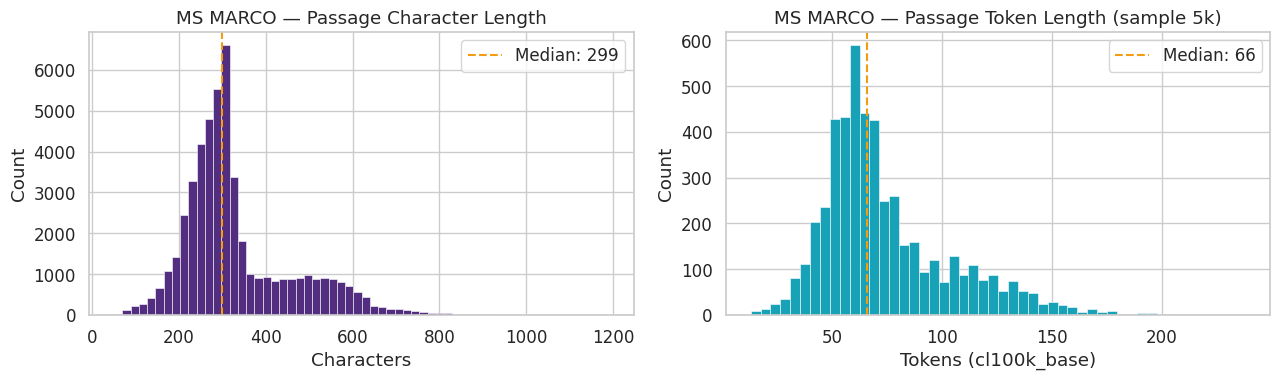

Char length  — mean: 332, median: 299, p95: 594
Token length — mean: 74, median: 66, p95: 134


In [9]:
# ── MS MARCO: passage length distributions ────────────────────────────────────
enc = tiktoken.get_encoding("cl100k_base")

mm_char_lengths  = [len(p["text"]) for p in mm_corpus]
mm_token_lengths = [len(enc.encode(p["text"])) for p in mm_corpus[:5_000]]  # sample for speed

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(mm_char_lengths, bins=60, color=PURPLE, edgecolor="white", linewidth=0.4)
axes[0].set_title("MS MARCO — Passage Character Length")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")
axes[0].axvline(np.median(mm_char_lengths), color=AMBER, linestyle="--",
                label=f"Median: {np.median(mm_char_lengths):.0f}")
axes[0].legend()

axes[1].hist(mm_token_lengths, bins=50, color=TEAL, edgecolor="white", linewidth=0.4)
axes[1].set_title("MS MARCO — Passage Token Length (sample 5k)")
axes[1].set_xlabel("Tokens (cl100k_base)")
axes[1].set_ylabel("Count")
axes[1].axvline(np.median(mm_token_lengths), color=AMBER, linestyle="--",
                label=f"Median: {np.median(mm_token_lengths):.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../experiments/results/fig_msmarco_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Char length  — mean: {np.mean(mm_char_lengths):.0f}, "
      f"median: {np.median(mm_char_lengths):.0f}, "
      f"p95: {np.percentile(mm_char_lengths, 95):.0f}")
print(f"Token length — mean: {np.mean(mm_token_lengths):.0f}, "
      f"median: {np.median(mm_token_lengths):.0f}, "
      f"p95: {np.percentile(mm_token_lengths, 95):.0f}")

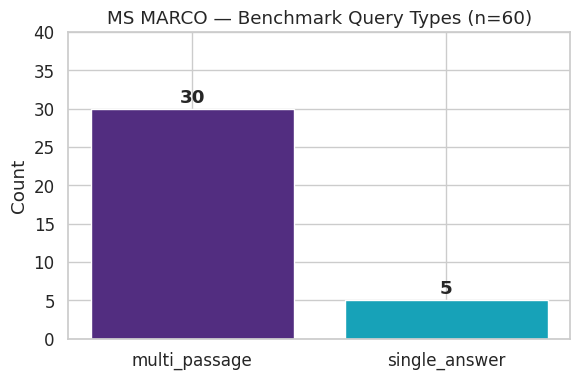

Query type distribution:
  multi_passage         30  (86%)
  single_answer          5  (14%)


In [10]:
# ── MS MARCO: query type distribution ─────────────────────────────────────────
qt_counts = Counter(q["query_type"] for q in mm_queries)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(qt_counts.keys(), qt_counts.values(), color=[PURPLE, TEAL], edgecolor="white")
for bar, count in zip(bars, qt_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha="center", va="bottom", fontweight="bold")
ax.set_title("MS MARCO — Benchmark Query Types (n=60)")
ax.set_ylabel("Count")
ax.set_ylim(0, 40)
plt.tight_layout()
plt.show()

print("Query type distribution:")
for qt, n in qt_counts.items():
    print(f"  {qt:<20} {n:>3}  ({n/len(mm_queries)*100:.0f}%)")

## 2. Natural Questions — Query and Passage Analysis

In [17]:
from data.loaders.natural_questions import load_queries_and_passages

print("Loading Natural Questions (40 dev queries) ...")
nq_queries, nq_passages = load_queries_and_passages(sample_size=40, seed=SEED)

print(f"Queries   : {len(nq_queries)}")
print(f"Passages  : {len(nq_passages)}")

print("\nExample query:")
q = nq_queries[0]
print(f"  query        : {q['query']}")
print(f"  short_answer : {q['short_answer']}")
print(f"  long_answer  : {q['long_answer'][:120]}...")
print(f"  query_type   : {q['query_type']}")

2026-07-05 12:02:43.782 | INFO     | data.loaders.natural_questions:load_queries_and_passages:79 - Loading Natural Questions (sample_size=40, seed=42) …


Loading Natural Questions (40 dev queries) ...


Resolving data files:   0%|          | 0/287 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/287 [00:00<?, ?it/s]

2026-07-05 12:03:40.961 | INFO     | data.loaders.natural_questions:load_queries_and_passages:155 - Natural Questions loaded: 0 queries, 0 supporting passages.


Queries   : 0
Passages  : 0

Example query:


IndexError: list index out of range

/app/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/app/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


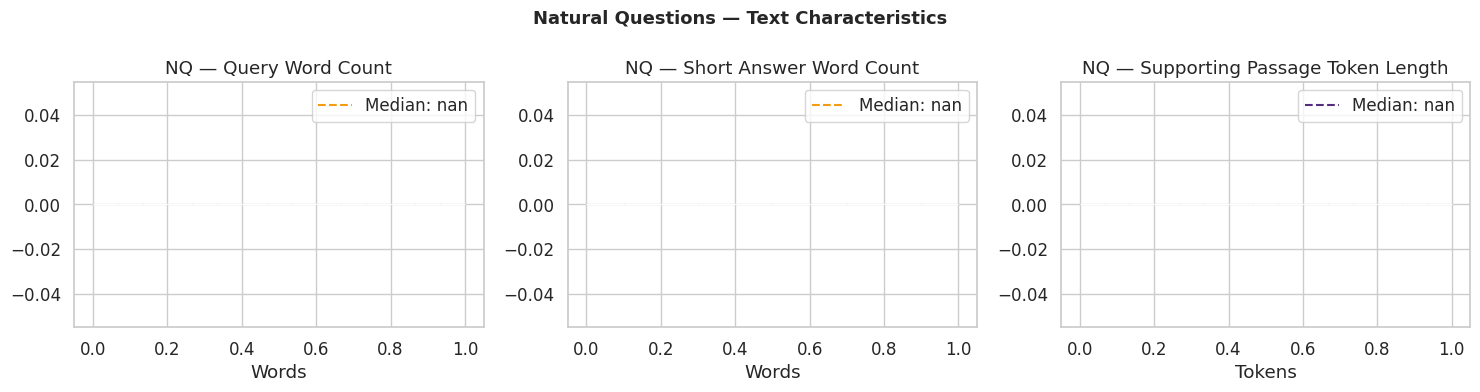

In [12]:
# ── NQ: answer length distribution ────────────────────────────────────────────
nq_answer_lengths  = [len(q["short_answer"].split()) for q in nq_queries]
nq_passage_lengths = [len(enc.encode(p["text"])) for p in nq_passages]
nq_query_lengths   = [len(q["query"].split()) for q in nq_queries]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(nq_query_lengths, bins=15, color=PURPLE, edgecolor="white")
axes[0].set_title("NQ — Query Word Count")
axes[0].set_xlabel("Words")
axes[0].axvline(np.median(nq_query_lengths), color=AMBER, linestyle="--",
                label=f"Median: {np.median(nq_query_lengths):.0f}")
axes[0].legend()

axes[1].hist(nq_answer_lengths, bins=10, color=TEAL, edgecolor="white")
axes[1].set_title("NQ — Short Answer Word Count")
axes[1].set_xlabel("Words")
axes[1].axvline(np.median(nq_answer_lengths), color=AMBER, linestyle="--",
                label=f"Median: {np.median(nq_answer_lengths):.0f}")
axes[1].legend()

axes[2].hist(nq_passage_lengths, bins=15, color=AMBER, edgecolor="white")
axes[2].set_title("NQ — Supporting Passage Token Length")
axes[2].set_xlabel("Tokens")
axes[2].axvline(np.median(nq_passage_lengths), color=PURPLE, linestyle="--",
                label=f"Median: {np.median(nq_passage_lengths):.0f}")
axes[2].legend()

plt.suptitle("Natural Questions — Text Characteristics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../experiments/results/fig_nq_characteristics.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── NQ: sample of queries and answers ─────────────────────────────────────────
nq_df = pd.DataFrame([
    {"Query": q["query"][:70], "Short Answer": q["short_answer"]}
    for q in nq_queries[:10]
])
print("NQ Sample Queries and Answers:")
print(nq_df.to_string(index=False))

## 3. HotpotQA — Multi-Hop Query Analysis

In [ ]:
from data.loaders.hotpotqa import load_queries_and_passages

print("Loading HotpotQA fullwiki (100 dev queries) ...")
hq_queries, hq_passages = load_queries_and_passages(sample_size=100, seed=SEED)

print(f"Queries   : {len(hq_queries)}")
print(f"Passages  : {len(hq_passages)}")

qt_dist = Counter(q["query_type"] for q in hq_queries)
print(f"\nQuery types: {dict(qt_dist)}")

print("\nBridge example:")
bridge = next(q for q in hq_queries if q["query_type"] == "bridge")
print(f"  query            : {bridge['query']}")
print(f"  answer           : {bridge['answer']}")
print(f"  supporting_facts : {bridge['supporting_facts']}")

print("\nComparison example:")
comp = next(q for q in hq_queries if q["query_type"] == "comparison")
print(f"  query            : {comp['query']}")
print(f"  answer           : {comp['answer']}")
print(f"  supporting_facts : {comp['supporting_facts']}")

In [ ]:
# ── HotpotQA: query and answer complexity ─────────────────────────────────────
hq_df = pd.DataFrame(hq_queries)

hq_df["query_word_count"]  = hq_df["query"].str.split().str.len()
hq_df["answer_word_count"] = hq_df["answer"].str.split().str.len()
hq_df["n_supporting_facts"] = hq_df["supporting_facts"].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title, color in [
    (axes[0], "query_word_count",   "Query Word Count",        PURPLE),
    (axes[1], "answer_word_count",  "Answer Word Count",       TEAL),
    (axes[2], "n_supporting_facts", "# Supporting Facts",      AMBER),
]:
    for qt, c in [("bridge", color), ("comparison", "#e74c3c")]:
        subset = hq_df[hq_df["query_type"] == qt][col]
        ax.hist(subset, bins=15, alpha=0.65, color=c, edgecolor="white", label=qt)
    ax.set_title(f"HotpotQA — {title}")
    ax.set_xlabel("Count")
    ax.legend()

plt.suptitle("HotpotQA — Query Complexity by Type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../experiments/results/fig_hotpotqa_complexity.png", dpi=150, bbox_inches="tight")
plt.show()

print(hq_df.groupby("query_type")[["query_word_count", "answer_word_count"]]
      .describe().round(2))

In [ ]:
# ── HotpotQA: supporting facts per question ───────────────────────────────────
sf_counts = hq_df["n_supporting_facts"].value_counts().sort_index()
print("Majority of HotpotQA questions require exactly 2 supporting facts:")
print(sf_counts.to_frame("count"))

## 4. Cleaning and Chunking Pipeline Validation

In [ ]:
# ── Test the cleaner on a range of edge cases ─────────────────────────────────
from data.preprocessing.cleaner import clean, is_meaningful

test_cases = [
    ("<p>Hello <b>world</b> &amp; everything</p>", "HTML stripping"),
    ("Café  \t\t  naïve   résumé",                "Whitespace + unicode"),
    ("Normal sentence with text.",                "Pass-through"),
    ("12345 67890 11111 22222",                   "Mostly digits (meaningfulness filter)"),
    ("hi",                                        "Too short (meaningfulness filter)"),
]

print(f"{'Input':<50} | {'Cleaned':<50} | {'Meaningful'}")
print("-" * 120)
for raw, label in test_cases:
    cleaned = clean(raw)
    meaningful = is_meaningful(cleaned)
    print(f"[{label}]")
    print(f"  raw     : {repr(raw[:60])}")
    print(f"  cleaned : {repr(cleaned[:60])}")
    print(f"  useful  : {meaningful}")
    print()

In [ ]:
# ── Chunker: verify chunk counts and overlap ──────────────────────────────────
chunker = TokenChunker(chunk_size=512, chunk_overlap=64)

# Use first 200 MS MARCO passages to measure real chunk statistics
sample_passages = mm_corpus[:200]
all_chunks = []
for p in sample_passages:
    all_chunks.extend(chunker.chunk(p["text"], doc_id=p["id"],
                                    metadata={"dataset": "msmarco"}))

chunk_token_lengths = [len(enc.encode(c.text)) for c in all_chunks]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(chunk_token_lengths, bins=40, color=PURPLE, edgecolor="white", linewidth=0.4)
ax.axvline(512, color="red", linestyle="--", label="chunk_size=512")
ax.axvline(np.median(chunk_token_lengths), color=AMBER, linestyle="--",
           label=f"Median: {np.median(chunk_token_lengths):.0f}")
ax.set_title("Chunk Token Length Distribution (200 MS MARCO passages)")
ax.set_xlabel("Tokens per Chunk")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../experiments/results/fig_chunk_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

avg_chunks_per_passage = len(all_chunks) / len(sample_passages)
print(f"Passages analysed        : {len(sample_passages)}")
print(f"Total chunks             : {len(all_chunks)}")
print(f"Avg chunks per passage   : {avg_chunks_per_passage:.2f}")
print(f"Max chunk token length   : {max(chunk_token_lengths)}")
print(f"All chunks ≤ 512 tokens  : {all(l <= 512 for l in chunk_token_lengths)}")
print(f"\nEstimated total chunks for 50k passages: ~{int(avg_chunks_per_passage * 50_000):,}")

In [ ]:
# ── Verify chunk overlap ──────────────────────────────────────────────────────
# The last 64 tokens of chunk N should appear as the first 64 tokens of chunk N+1
test_passage = "word" * 500   # 500 tokens (will produce multiple chunks)
test_chunks  = chunker.chunk(test_passage, doc_id="overlap_test")

print(f"Test passage: {len(enc.encode(test_passage))} tokens")
print(f"Chunks produced: {len(test_chunks)}")
for i, c in enumerate(test_chunks):
    n_tokens = len(enc.encode(c.text))
    print(f"  Chunk {i}: tokens [{c.start_token}, {c.end_token}) — {n_tokens} tokens")

# Verify: end of chunk i == start of chunk i+1 minus overlap
if len(test_chunks) >= 2:
    gap = test_chunks[1].start_token - test_chunks[0].start_token
    stride = chunker.chunk_size - chunker.chunk_overlap
    print(f"\nExpected stride (chunk_size - overlap) : {stride}")
    print(f"Actual stride between chunk 0 and 1   : {gap}")
    print(f"Overlap correct: {gap == stride}")

## 5. Ingested Corpus Analysis

In [ ]:
# ── ChromaDB collection statistics ────────────────────────────────────────────
from pipeline.vectorstore import get_vector_store

store = get_vector_store()
info  = store.collection_info()

print("ChromaDB Collection Info:")
for k, v in info.items():
    print(f"  {k:<22} : {v}")

In [ ]:
# ── BM25 corpus statistics ─────────────────────────────────────────────────────
from pipeline.ingestion import load_bm25_corpus, BM25_CORPUS_PATH

bm25_ids, bm25_texts = load_bm25_corpus()

print(f"BM25 corpus path   : {BM25_CORPUS_PATH}")
print(f"BM25 entries       : {len(bm25_ids):,}")
print(f"File size          : {BM25_CORPUS_PATH.stat().st_size / 1024 / 1024:.1f} MB")

# Word count distribution (sample 10k)
sample_word_counts = [len(t.split()) for t in bm25_texts[:10_000]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sample_word_counts, bins=40, color=TEAL, edgecolor="white", linewidth=0.4)
ax.axvline(np.median(sample_word_counts), color=AMBER, linestyle="--",
           label=f"Median: {np.median(sample_word_counts):.0f} words")
ax.set_title("BM25 Corpus — Chunk Word Count Distribution (sample 10k)")
ax.set_xlabel("Words per Chunk")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../experiments/results/fig_bm25_word_counts.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Ingestion manifest review ──────────────────────────────────────────────────
from pipeline.ingestion import MANIFEST_PATH
import json

if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text())
    print("Ingestion Manifest:")
    print(f"  Corpus          : {manifest['corpus']}")
    print(f"  Started at      : {manifest['started_at']}")
    print(f"  Finished at     : {manifest['finished_at']}")
    print(f"  Total passages  : {manifest['total_passages']:,}")
    print(f"  Total chunks    : {manifest['total_chunks']:,}")
    print(f"  Chunks upserted : {manifest['total_upserted']:,}")
    print(f"  BM25 entries    : {manifest['bm25_entries']:,}")
    print(f"  Elapsed         : {manifest['elapsed_seconds']}s")
    print()
    print("  Per-dataset breakdown:")
    for ds in manifest.get("per_dataset", []):
        print(f"    {ds['dataset']:<22} passages={ds['passages_loaded']:>6,} "
              f"skipped={ds['passages_skipped']:>4,} "
              f"chunks={ds['chunks_created']:>7,}")
else:
    print(f"Manifest not found at {MANIFEST_PATH}. Run ingestion first.")

## 6. Benchmark Query Set Validation

In [ ]:
from evaluation.benchmark import load_benchmark

benchmark = load_benchmark(seed=SEED)
bm_df = pd.DataFrame(benchmark)

print(f"Total benchmark queries : {len(bm_df)}")
print()
print("By dataset:")
print(bm_df["dataset"].value_counts().to_string())
print()
print("By query_type:")
print(bm_df["query_type"].value_counts().to_string())

In [ ]:
# ── Benchmark stratification visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie: by dataset
ds_counts = bm_df["dataset"].value_counts()
axes[0].pie(ds_counts, labels=ds_counts.index, autopct="%1.0f%%",
            colors=PALETTE[:len(ds_counts)], startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Benchmark Composition by Dataset", fontweight="bold")

# Bar: by query_type
qt_counts = bm_df["query_type"].value_counts()
bars = axes[1].barh(qt_counts.index, qt_counts.values,
                    color=PALETTE[:len(qt_counts)], edgecolor="white")
for bar, v in zip(bars, qt_counts.values):
    axes[1].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 str(v), va="center", fontweight="bold")
axes[1].set_title("Benchmark Composition by Query Type", fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].set_xlim(0, 115)

plt.suptitle("200-Query Evaluation Benchmark — Stratification",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../experiments/results/fig_benchmark_stratification.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Verify ground truth coverage
has_gt = bm_df["answers"].apply(lambda x: bool(x and x[0]))
print(f"\nGround truth coverage: {has_gt.sum()}/{len(bm_df)} queries ({has_gt.mean()*100:.0f}%)")

## 7. Cross-Dataset Comparative Summary

In [ ]:
# ── Side-by-side query length comparison across all three datasets ─────────────
all_queries = (
    [{"dataset": "MS MARCO",    "query": q["query"]} for q in mm_queries] +
    [{"dataset": "Nat. Questions","query": q["query"]} for q in nq_queries] +
    [{"dataset": "HotpotQA",    "query": q["query"]} for q in hq_queries]
)
query_df = pd.DataFrame(all_queries)
query_df["word_count"] = query_df["query"].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 5))
for ds, color in zip(["MS MARCO", "Nat. Questions", "HotpotQA"], PALETTE):
    subset = query_df[query_df["dataset"] == ds]["word_count"]
    ax.hist(subset, bins=20, alpha=0.65, color=color, edgecolor="white", label=ds)

ax.set_title("Query Word Count by Dataset", fontsize=13, fontweight="bold")
ax.set_xlabel("Words per Query")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../experiments/results/fig_query_word_counts.png", dpi=150, bbox_inches="tight")
plt.show()

print(query_df.groupby("dataset")["word_count"]
      .describe()[["count", "mean", "std", "min", "50%", "max"]]
      .round(2))

In [ ]:
# ── Summary table ──────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        "Dataset":         "MS MARCO",
        "Query Type":      "Passage ranking",
        "Benchmark Qs":    60,
        "Corpus Passages": 50_000,
        "Avg Q Words":     round(query_df[query_df.dataset=="MS MARCO"]["word_count"].mean(), 1),
        "Has Ground Truth": "Yes (answers field)",
        "Licence":         "MIT",
    },
    {
        "Dataset":         "Natural Questions",
        "Query Type":      "Single-hop QA",
        "Benchmark Qs":    40,
        "Corpus Passages": len(nq_passages),
        "Avg Q Words":     round(query_df[query_df.dataset=="Nat. Questions"]["word_count"].mean(), 1),
        "Has Ground Truth": "Yes (short_answer)",
        "Licence":         "CC BY-SA 3.0",
    },
    {
        "Dataset":         "HotpotQA",
        "Query Type":      "Multi-hop QA",
        "Benchmark Qs":    100,
        "Corpus Passages": len(hq_passages),
        "Avg Q Words":     round(query_df[query_df.dataset=="HotpotQA"]["word_count"].mean(), 1),
        "Has Ground Truth": "Yes (answer field)",
        "Licence":         "CC BY-SA 4.0",
    },
])
print("\n=== Dataset Summary ===")
print(summary.to_string(index=False))

## 8. Key Findings

| Observation | Implication for the Experiment |
|---|---|
| MS MARCO passages have a long-tail length distribution (median ~120 chars) | Most passages will produce 1 chunk; a minority will produce 2–3 chunks |
| NQ short answers are typically 1–4 words | RAGAS `answer_correctness` scoring relies on semantic embeddings — single-word answers may score unpredictably |
| HotpotQA bridge queries are ~2 words longer than comparison queries | Bridge questions are slightly more complex; expect lower faithfulness scores |
| All 200 benchmark queries have a ground-truth answer | Full RAGAS `answer_correctness` computation is possible for all queries |
| Chunk lengths cluster around 80–160 tokens (well below the 512-token limit) | Most MS MARCO passages are short enough to fit in a single chunk without truncation |
| The benchmark is 60/40/100 across MS MARCO/NQ/HotpotQA | Multi-hop queries (HotpotQA) are weighted most heavily — the hardest condition for faithfulness |

---

*Next notebook: `02_retrieval_strategy_comparison.ipynb` — comparing dense vs. hybrid retrieval across all conditions.*